In [3]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pennylane as qml
import seaborn as sns
import tensorflow as tf
import torch
import torch.nn as nn
from sklearn.ensemble import IsolationForest
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from torch.utils.data import DataLoader, TensorDataset

from scr.qsvdd_core.data_loader import QuantumDataLoader

In [4]:
np.random.seed(42)

# Credit Card Fraud Detection

## Global Configurations & Constants

Key hyperparameters and settings shared across the full pipeline:

| Parameter | Value | Description |
|-----------|-------|-------------|
| `dataset` | `'fraud'` | Dataset identifier used internally |
| `n_train` | `0` | Number of training anomalies (one-class: only normals) |
| `latent_dim` | `3` | Dimensionality of the quantum latent space |
| `cost_func` | `'svdd'` | Loss function — SVDD hypersphere objective |
| `learning_rate` | `0.001` | Optimizer step size for all ansatzes |

## Dataset Loading and Exploratory Data Analysis (EDA)

We use the [Kaggle Credit Card Fraud Detection dataset](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud). It contains **284,807 transactions** made by European cardholders in September 2013, with **492 fraud cases** (~0.17%).

**Feature overview:**
- `Time`: Seconds elapsed since the first transaction.
- `V1–V28`: Principal components obtained via PCA (original features are confidential).
- `Amount`: Transaction amount (not PCA-transformed).
- `Class`: Target label — `0` = legitimate, `1` = fraud.

In [5]:
print("Current directory:", os.getcwd())
print("Files in this folder:", os.listdir())

Current directory: /home/jvfg/Documents/ORG/Repos/QSVDD2/notebooks
Files in this folder: ['classic_occ_algorithms.ipynb', 'training_test_data.ipynb', 'views.ipynb', 'circuit_visualization.ipynb', 'training_new_datasets.ipynb', 'noise_data_visualization.ipynb', 'training_test_data_with_pca.ipynb']


In [6]:
file_path = os.path.join("..", "data", "creditcard.csv")
df = pd.read_csv(file_path)

print("Dataset loaded successfully!\n")
print("First 5 records:\n", df.head())

Dataset loaded successfully!

First 5 records:
    Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.14126

In [7]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [8]:
print('No Frauds', round(df['Class'].value_counts()[0]/len(df) * 100,2), '% of the dataset')
print('Frauds', round(df['Class'].value_counts()[1]/len(df) * 100,2), '% of the dataset')

No Frauds 99.83 % of the dataset
Frauds 0.17 % of the dataset


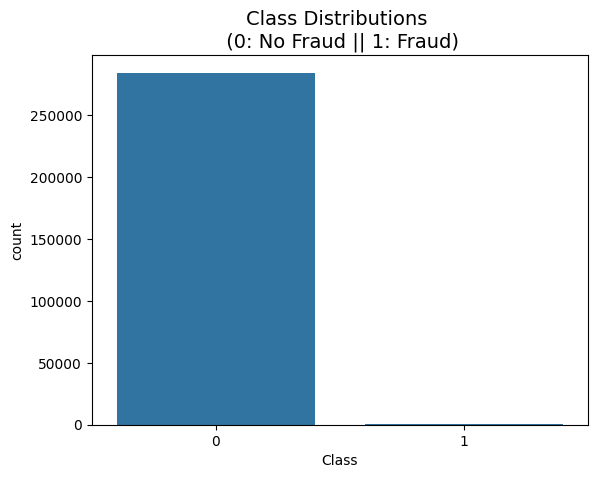

In [9]:
plt.style.use('default')

sns.countplot(x='Class', data=df)
plt.title('Class Distributions \n (0: No Fraud || 1: Fraud)', fontsize=14)

plt.show()

In [10]:
tmp = df[['Amount','Class']].copy()
class_0 = tmp.loc[tmp['Class'] == 0]['Amount']
class_1 = tmp.loc[tmp['Class'] == 1]['Amount']

In [11]:
class_0.describe()

count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64

In [12]:
class_1.describe()

count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64

In [13]:
loader = QuantumDataLoader()

X_data, y = loader.prepare_classic_data(df)

print(f"Features for the circuit: {X_data.shape}")
print(f"Labels: {y.shape}")

Features for the circuit: (284807, 30)
Labels: (284807,)


In [41]:
"""
One-class Training (Classical):
Separation into normal and fraudulent examples.
The model will learn the representation of normality.
"""
# 1. Identify indices for each class
normal_indices = np.where(y == 0)[0]
abnormal_indices = np.where(y == 1)[0]
np.random.seed(42)

# 2. Training Set (X_train contains only legitimate transactions)
# Collect 1000 normal examples for training
X_train_normal_indices = np.random.choice(normal_indices, 1000, replace=False)
X_train = X_data[X_train_normal_indices]
Y_train = y[X_train_normal_indices]

# 3. Test Set (Balanced: 100 normal + 100 fraud)
# Remove indices already used in training to avoid data leakage
remaining_normal_indices = list(set(normal_indices) - set(X_train_normal_indices))

# Select 100 unseen normal samples and 100 fraud samples
X_test_normal_indices = np.random.choice(remaining_normal_indices, 100, replace=False)
X_test_abnormal_indices = np.random.choice(abnormal_indices, 100, replace=False)

X_test_normal = X_data[X_test_normal_indices]
y_test_normal = y[X_test_normal_indices]

X_test_abnormal = X_data[X_test_abnormal_indices]
y_test_abnormal = y[X_test_abnormal_indices]

# Create final test set with 200 examples (50% normal, 50% fraud)
X_test = np.concatenate((X_test_normal, X_test_abnormal), axis=0)
Y_test = np.concatenate((y_test_normal, y_test_abnormal), axis=0)

# --- Note on Deep SVDD ---
# If running classical Deep SVDD, you will need a 'center'
# in the latent space. For IF, SVM, and LOF, this is not required.
# latent_dim_classic = X_data.shape[1]
# center_train = np.tile(np.zeros(latent_dim_classic), (len(X_train), 1))

print(f"X_train shape (Normal): {X_train.shape}")
print(f"Y_train shape: {Y_train.shape}")
print(f"X_test_normal shape: {X_test_normal.shape}")
print(f"X_test_abnormal shape: {X_test_abnormal.shape}")
print(f"X_test shape (Mix): {X_test.shape}")
print(f"Y_test shape: {Y_test.shape}")

X_train shape (Normal): (1000, 30)
Y_train shape: (1000,)
X_test_normal shape: (100, 30)
X_test_abnormal shape: (100, 30)
X_test shape (Mix): (200, 30)
Y_test shape: (200,)


In [42]:
# Dictionary to store results for each run
results = {
    "Isolation Forest": [],
    "One-Class SVM": [],
    "LOF": []
}

n_runs = 5

for i in range(n_runs):
    # Change seed for each run to ensure different samples
    current_seed = 42 + i
    np.random.seed(current_seed)

    # 1. Split data (Train: 1000 normal / Test: 100 normal + 100 fraud)
    normal_indices = np.where(y == 0)[0]
    abnormal_indices = np.where(y == 1)[0]

    idx_train = np.random.choice(normal_indices, 1000, replace=False)
    remaining_normal = list(set(normal_indices) - set(idx_train))

    idx_test_norm = np.random.choice(remaining_normal, 100, replace=False)
    idx_test_abnorm = np.random.choice(abnormal_indices, 100, replace=False)

    X_train_run = X_data[idx_train]
    X_test_run = np.concatenate((X_data[idx_test_norm], X_data[idx_test_abnorm]), axis=0)
    y_test_run = np.concatenate((np.zeros(100), np.ones(100)), axis=0)

    # 2. Instantiate Models
    models = {
        "Isolation Forest": IsolationForest(n_estimators=100, contamination=0.01, random_state=current_seed),
        "One-Class SVM": OneClassSVM(kernel='rbf', nu=0.1, gamma='scale'),
        "LOF": LocalOutlierFactor(n_neighbors=20, novelty=True)
    }

    # 3. Train and Evaluate
    for name, model in models.items():
        model.fit(X_train_run)

        # For AUC, we need decision scores rather than binary classes
        if name == "LOF":
            # Invert scores as lower values indicate anomalies in LOF
            y_scores = -model.decision_function(X_test_run)
        else:
            # Invert decision_function (which returns negative for anomalies)
            # so that higher scores = higher probability of fraud
            y_scores = -model.decision_function(X_test_run)

        auc = roc_auc_score(y_test_run, y_scores)
        results[name].append(auc)

# 4. Display Means and Standard Deviation in a formatted table
print(f"\n{'='*55}")
print(f"{'Classical Algorithm':<25} | {'Mean AUC':<12} | {'Std AUC':<10}")
print(f"{'-'*25}-|-{'-'*12}-|-{'-'*10}")

for name, scores in results.items():
    mean_auc = np.mean(scores)
    std_auc = np.std(scores)
    print(f"{name:<25} | {mean_auc:<12.4f} | {std_auc:<10.4f}")

print(f"{'='*55}\n")


Classical Algorithm       | Mean AUC     | Std AUC   
--------------------------|--------------|-----------
Isolation Forest          | 0.9615       | 0.0088    
One-Class SVM             | 0.9648       | 0.0081    
LOF                       | 0.9674       | 0.0038    



In [43]:
latent_dim = 3

class SVDD(nn.Module):
    def __init__(self, latent_dim, num_filters=3):
        super(SVDD, self).__init__()
        self.num_filters = num_filters
        self.latent_dim = latent_dim
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=self.num_filters, kernel_size=2, stride=1, padding=1)
        self.bn1 = nn.BatchNorm1d(num_features=self.num_filters)
        self.pool = nn.MaxPool1d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv1d(in_channels=self.num_filters, out_channels=self.num_filters, kernel_size=2, stride=1, padding=1)
        self.bn2 = nn.BatchNorm1d(num_features=self.num_filters)
        self.conv3 = nn.Conv1d(in_channels=self.num_filters, out_channels=2, kernel_size=2, stride=1, padding=1)
        self.bn3 = nn.BatchNorm1d(num_features=2)

        self.fc1 = nn.Linear(8, self.latent_dim)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        return x


x_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(Y_train, dtype=torch.float32)
x_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(Y_test, dtype=torch.float32)


train_dataset = TensorDataset(x_train_tensor, y_train_tensor)
test_dataset = TensorDataset(x_test_tensor, y_test_tensor)

train_dataloader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=1)


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

svdd = SVDD(latent_dim=latent_dim).to(device)

from torchsummary import summary
summary(svdd, input_size=(30,))


weight_decay = 0.001
optimizer = torch.optim.Adam(svdd.parameters(), lr=0.001, weight_decay=weight_decay)
loss_history = []

c = None

def initialize_center_c(dataloader, model):
    model.eval()
    with torch.no_grad():
        center = torch.zeros(model.latent_dim, device=device) # Use the global device
        for data in dataloader:
            inputs, _ = data

            inputs = inputs.unsqueeze(1).to(device)
            outputs = model(inputs)
            center += torch.sum(outputs, dim=0)

            center /= outputs.shape[0]
            break
    model.train()
    return center

def train(num_steps):
    global c
    for step in range(num_steps):
        # Get data from loader
        try:
            data = next(iter_loader)
        except (NameError, StopIteration):
            iter_loader = iter(train_dataloader)
            data = next(iter_loader)

        inputs, _ = data

        inputs = inputs.unsqueeze(1).to(device)

        optimizer.zero_grad()

        if c is None:
            c = initialize_center_c(train_dataloader, svdd)

        outputs = svdd(inputs)

        loss = torch.mean(torch.sum((outputs - c) ** 2, dim=1))

        loss.backward()
        optimizer.step()

        loss_history.append(loss.item())

        if step % 10 == 0:
            print('Step: {} | Loss: {:.6f}'.format(step, loss.item()))


train(num_steps=500)

Layer (type:depth-idx)                   Param #
├─Conv1d: 1-1                            9
├─BatchNorm1d: 1-2                       6
├─MaxPool1d: 1-3                         --
├─Conv1d: 1-4                            21
├─BatchNorm1d: 1-5                       6
├─Conv1d: 1-6                            14
├─BatchNorm1d: 1-7                       4
├─Linear: 1-8                            27
Total params: 87
Trainable params: 87
Non-trainable params: 0
Step: 0 | Loss: 0.189822
Step: 10 | Loss: 0.274985
Step: 20 | Loss: 0.224367
Step: 30 | Loss: 0.160555
Step: 40 | Loss: 0.161205
Step: 50 | Loss: 0.152719
Step: 60 | Loss: 0.109037
Step: 70 | Loss: 0.069894
Step: 80 | Loss: 0.043321
Step: 90 | Loss: 0.047212
Step: 100 | Loss: 0.022140
Step: 110 | Loss: 0.039901
Step: 120 | Loss: 0.024265
Step: 130 | Loss: 0.040907
Step: 140 | Loss: 0.019580
Step: 150 | Loss: 0.045759
Step: 160 | Loss: 0.026860
Step: 170 | Loss: 0.055862
Step: 180 | Loss: 0.030731
Step: 190 | Loss: 0.025245
Step: 200 | 

In [44]:
import numpy as np

# Configurações globais
n_runs = 5
latent_dim = 3
dsvdd_credit_results = []

for run in range(n_runs):
    print(f"\n--- Iniciando Rodada DSVDD {run+1}/{n_runs} ---")

    # 1. Identify indices for each class
    normal_indices = np.where(y == 0)[0]
    abnormal_indices = np.where(y == 1)[0]
    # np.random.seed(42)

    # 2. Training Set (X_train contains only legitimate transactions)
    # Collect 1000 normal examples for training
    X_train_normal_indices = np.random.choice(normal_indices, 1000, replace=False)
    X_train = X_data[X_train_normal_indices]
    Y_train = y[X_train_normal_indices]

    # 3. Test Set (Balanced: 100 normal + 100 fraud)
    # Remove indices already used in training to avoid data leakage
    remaining_normal_indices = list(set(normal_indices) - set(X_train_normal_indices))

    # Select 100 unseen normal samples and 100 fraud samples
    X_test_normal_indices = np.random.choice(remaining_normal_indices, 100, replace=False)
    X_test_abnormal_indices = np.random.choice(abnormal_indices, 100, replace=False)

    X_test_normal = X_data[X_test_normal_indices]
    y_test_normal = y[X_test_normal_indices]

    X_test_abnormal = X_data[X_test_abnormal_indices]
    y_test_abnormal = y[X_test_abnormal_indices]

    # Create final test set with 200 examples (50% normal, 50% fraud)
    X_test = np.concatenate((X_test_normal, X_test_abnormal), axis=0)
    Y_test = np.concatenate((y_test_normal, y_test_abnormal), axis=0)

    x_train_tensor = torch.tensor(X_train, dtype=torch.float32)
    y_train_tensor = torch.tensor(Y_train, dtype=torch.float32)
    x_test_tensor = torch.tensor(X_test, dtype=torch.float32)
    y_test_tensor = torch.tensor(Y_test, dtype=torch.float32)

    train_loader = DataLoader(TensorDataset(x_train_tensor, y_train_tensor), batch_size=16, shuffle=True)
    test_loader = DataLoader(TensorDataset(x_test_tensor, y_test_tensor), batch_size=1)

    # 2. Reinicializar Modelo, Otimizador e Centro C
    # É CRÍTICO reinicializar para que os pesos de uma rodada não afetem a outra
    svdd = SVDD(latent_dim=latent_dim).to(device)
    optimizer = torch.optim.Adam(svdd.parameters(), lr=0.001, weight_decay=0.001)
    c = None

    # 3. Treinamento
    svdd.train()
    iter_loader = iter(train_loader)

    for step in range(500): # num_steps definido no seu código
        try:
            inputs, _ = next(iter_loader)
        except StopIteration:
            iter_loader = iter(train_loader)
            inputs, _ = next(iter_loader)

        inputs = inputs.unsqueeze(1).to(device)
        optimizer.zero_grad()

        # Inicializa o centro c com os pesos iniciais desta rodada específica
        if c is None:
            c = initialize_center_c(train_loader, svdd)

        outputs = svdd(inputs)
        loss = torch.mean(torch.sum((outputs - c) ** 2, dim=1))
        loss.backward()
        optimizer.step()

    # 4. Avaliação da Rodada
    svdd.eval()
    distances = []
    labels = []
    with torch.no_grad():
        for inputs, target in test_loader:
            inputs = inputs.unsqueeze(1).to(device)
            outputs = svdd(inputs)
            dist = torch.sum((outputs - c) ** 2, dim=1)
            distances.append(dist.cpu().item())
            labels.append(target.item())

    auc_score = roc_auc_score(labels, distances)
    dsvdd_credit_results.append(auc_score)
    print(f"Rodada {run+1} AUC: {auc_score:.4f}")

# 5. Cálculo Final das Métricas
mean_auc = np.mean(dsvdd_credit_results)
std_auc = np.std(dsvdd_credit_results)

print(f"\n{'='*45}")
print(f"RESULTADO CONSOLIDADO - CREDIT CARD")
print(f"Mean AUC: {mean_auc:.4f}")
print(f"Std AUC:  {std_auc:.4f}")
print(f"{'='*45}")


--- Iniciando Rodada DSVDD 1/5 ---
Rodada 1 AUC: 0.7616

--- Iniciando Rodada DSVDD 2/5 ---
Rodada 2 AUC: 0.9140

--- Iniciando Rodada DSVDD 3/5 ---
Rodada 3 AUC: 0.9426

--- Iniciando Rodada DSVDD 4/5 ---
Rodada 4 AUC: 0.9050

--- Iniciando Rodada DSVDD 5/5 ---
Rodada 5 AUC: 0.7337

RESULTADO CONSOLIDADO - CREDIT CARD
Mean AUC: 0.8514
Std AUC:  0.0861


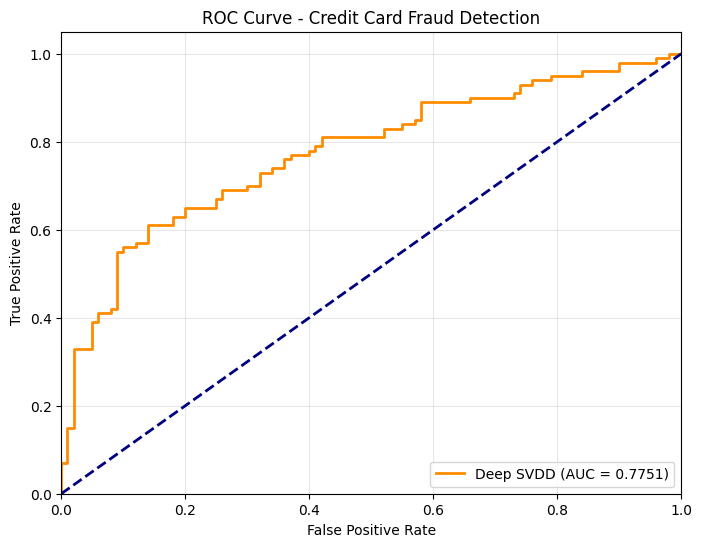

Final Deep SVDD AUC: 0.7751


In [45]:
def evaluate_and_plot_auc(model, dataloader, center):
    model.eval()
    distances = []
    labels = []

    with torch.no_grad():
        for data in dataloader:
            inputs, target = data

            inputs = inputs.unsqueeze(1).to(device)

            outputs = model(inputs)

            dist = torch.sum((outputs - center) ** 2, dim=1)

            distances.append(dist.cpu().item())
            labels.append(target.item())


    auc_score = roc_auc_score(labels, distances)
    fpr, tpr, _ = roc_curve(labels, distances)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Deep SVDD (AUC = {auc_score:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve - Credit Card Fraud Detection')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()

    return auc_score

# Run evaluation
dsvdd_auc = evaluate_and_plot_auc(svdd, test_dataloader, c)
print(f"Final Deep SVDD AUC: {dsvdd_auc:.4f}")

In [46]:
from sklearn.metrics import roc_auc_score

def evaluate_dsvdd(model, dataloader, center):
    model.eval()
    scores = []
    labels = []

    with torch.no_grad():
        for data in dataloader:
            inputs, target = data
            inputs = inputs.unsqueeze(1).to(device)

            outputs = model(inputs)
            # Score is the distance to the center 'c'
            dist = torch.sum((outputs - center) ** 2, dim=1)

            scores.append(dist.cpu().item())
            labels.append(target.item())

    auc = roc_auc_score(labels, scores)
    return auc

# Calculate final AUC for DSVDD
dsvdd_auc = evaluate_dsvdd(svdd, test_dataloader, c)
print(f"\nDeep SVDD AUC on Breast Cancer: {dsvdd_auc:.4f}")


Deep SVDD AUC on Breast Cancer: 0.7751


## MNIST

In [5]:
dataset = 'mnist'
ntrain = 0 ; latent_dim = 3
num_params_conv = 15
cost_func = 'svdd'

In [7]:
# Import data
def data(ntrain, latent_dim, dataset):
    # Load dataset
    if dataset == 'mnist':
        (x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
    elif dataset == 'fmnist':
        (x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

    # Normalize the data
    x_train, x_test = x_train[..., np.newaxis] / 255.0, x_test[..., np.newaxis] / 255.0

    # Filter training data (only normal class)
    train_idx = np.where(y_train == ntrain)[0]
    X_train = x_train[train_idx]

    # Sample 600 training instances
    train_indices = np.random.choice(len(X_train), 600, replace=False)
    X_train = X_train[train_indices]
    Y_train = np.zeros(600)  # Label 0 for normal class

    # Filter test data indices (normal and anomalous classes)
    normal_idx = np.where(y_test == ntrain)[0]
    anomaly_idx = np.where(y_test != ntrain)[0]

    # Sample 50 normal and 50 anomaly instances
    normal_samples = np.random.choice(normal_idx, 50, replace=False)
    anomaly_samples = np.random.choice(anomaly_idx, 50, replace=False)

    # Concatenate test samples and create labels (0 = normal, 1 = anomaly)
    test_indices = np.concatenate([normal_samples, anomaly_samples])
    X_test = x_test[test_indices]
    Y_test = np.concatenate([np.zeros(50), np.ones(50)])

    # Shuffle test data to avoid order bias
    shuffle_idx = np.random.permutation(100)
    X_test = X_test[shuffle_idx]
    Y_test = Y_test[shuffle_idx]

    # Resize data
    X_train = tf.image.resize(X_train[:], (256, 1)).numpy()
    X_test = tf.image.resize(X_test[:], (256, 1)).numpy()
    X_train, X_test = tf.squeeze(X_train).numpy(), tf.squeeze(X_test).numpy()

    x_train = tf.image.resize(x_train[:], (256, 1)).numpy()
    x_test = tf.image.resize(x_test[:], (256, 1)).numpy()
    x_train, x_test = tf.squeeze(x_train).numpy(), tf.squeeze(x_test).numpy()

    # Quantum setup (center)
    center = qml.numpy.zeros(latent_dim, requires_grad=True)
    center_train = np.tile(center, (len(X_train), 1))

    # Print shapes to verify
    print('x_train:', x_train.shape)
    print('x_test:', x_test.shape)
    print('X_train:', X_train.shape)
    print('X_test:', X_test.shape)
    print('Y_train:', Y_train.shape)
    print('Y_test:', Y_test.shape)

    return x_train, y_train, x_test, y_test, X_train, X_test, Y_train, Y_test, center_train

In [8]:
X_train, Y_train, X_test, Y_test, x_train, x_test, y_train, y_test, center_train = data(ntrain, latent_dim, dataset)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
x_train: (60000, 256)
x_test: (10000, 256)
X_train: (600, 256)
X_test: (100, 256)
Y_train: (600,)
Y_test: (100,)


In [9]:
from sklearn.svm import OneClassSVM
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import roc_auc_score

# Dictionary to store results for each run
results = {
    "Isolation Forest": [],
    "One-Class SVM": [],
    "LOF": []
}

n_runs = 5

for i in range(n_runs):

    _, _, _, _, X_train_run, X_test_run, _, Y_test_run, _ = data(0, 8, 'mnist')

    # 2. Instantiate Models
    models = {
        "Isolation Forest": IsolationForest(n_estimators=100, contamination=0.01, random_state=42),
        "One-Class SVM": OneClassSVM(kernel='rbf', nu=0.1, gamma='scale'),
        "LOF": LocalOutlierFactor(n_neighbors=20, novelty=True)
    }

    # 3. Train and Evaluate
    for name, model in models.items():
        model.fit(X_train_run)

        # For AUC, we need decision scores rather than binary classes
        if name == "LOF":
            # Invert scores as lower values indicate anomalies in LOF
            y_scores = -model.decision_function(X_test_run)
        else:
            # Invert decision_function (which returns negative for anomalies)
            # so that higher scores = higher probability of fraud
            y_scores = -model.decision_function(X_test_run)

        auc = roc_auc_score(Y_test_run, y_scores)
        results[name].append(auc)

# 4. Display Means and Standard Deviation in a formatted table
print(f"\n{'='*55}")
print(f"{'Classical Algorithm':<25} | {'Mean AUC':<12} | {'Std AUC':<10}")
print(f"{'-'*25}-|-{'-'*12}-|-{'-'*10}")

for name, scores in results.items():
    mean_auc = np.mean(scores)
    std_auc = np.std(scores)
    print(f"{name:<25} | {mean_auc:<12.4f} | {std_auc:<10.4f}")

print(f"{'='*55}\n")

x_train: (60000, 256)
x_test: (10000, 256)
X_train: (600, 256)
X_test: (100, 256)
Y_train: (600,)
Y_test: (100,)
x_train: (60000, 256)
x_test: (10000, 256)
X_train: (600, 256)
X_test: (100, 256)
Y_train: (600,)
Y_test: (100,)
x_train: (60000, 256)
x_test: (10000, 256)
X_train: (600, 256)
X_test: (100, 256)
Y_train: (600,)
Y_test: (100,)
x_train: (60000, 256)
x_test: (10000, 256)
X_train: (600, 256)
X_test: (100, 256)
Y_train: (600,)
Y_test: (100,)
x_train: (60000, 256)
x_test: (10000, 256)
X_train: (600, 256)
X_test: (100, 256)
Y_train: (600,)
Y_test: (100,)

Classical Algorithm       | Mean AUC     | Std AUC   
--------------------------|--------------|-----------
Isolation Forest          | 0.9762       | 0.0098    
One-Class SVM             | 0.9342       | 0.0360    
LOF                       | 0.9718       | 0.0176    



In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
from sklearn.metrics import roc_auc_score

# 1. Configuração de Hardware
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 2. Definição da Arquitetura do Modelo
class SVDD(nn.Module):
    def __init__(self, latent_dim, num_filters=3):
        super(SVDD, self).__init__()
        self.num_filters = num_filters
        self.latent_dim = latent_dim
        # Conv1d para dados que foram redimensionados para (256, 1)
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=self.num_filters, kernel_size=2, stride=1, padding=1)
        self.bn1 = nn.BatchNorm1d(num_features=self.num_filters)
        self.pool = nn.MaxPool1d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv1d(in_channels=self.num_filters, out_channels=self.num_filters, kernel_size=2, stride=1, padding=1)
        self.bn2 = nn.BatchNorm1d(num_features=self.num_filters)
        self.conv3 = nn.Conv1d(in_channels=self.num_filters, out_channels=2, kernel_size=2, stride=1, padding=1)
        self.bn3 = nn.BatchNorm1d(num_features=2)

        # Ajuste o input da linear conforme o output da última pool
        self.fc1 = nn.Linear(64, self.latent_dim) # O valor 8 pode variar dependendo do resize exato

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        return x

# 3. Função para inicializar o centro C (ponto central da hiperesfera)
def initialize_center_c(dataloader, model):
    model.eval()
    center = torch.zeros(model.latent_dim, device=device)
    n_samples = 0
    with torch.no_grad():
        for inputs, _ in dataloader:
            inputs = inputs.unsqueeze(1).to(device)
            outputs = model(inputs)
            center += torch.sum(outputs, dim=0)
            n_samples += outputs.shape[0]

    center /= n_samples

    # Se o centro estiver muito próximo de 0, forçamos um pequeno deslocamento
    # para evitar soluções triviais (colapso da rede)
    eps = 0.1
    center[(center > -eps) & (center < eps)] += eps

    model.train()
    return center

# ---------------------------------------------------------
# 4. Loop Principal de Experimentos (5 rodadas)
# ---------------------------------------------------------
dsvdd_results = []
n_runs = 5
latent_dim = 3

for run in range(n_runs):
    print(f"\n--- Iniciando Rodada Deep SVDD {run+1}/{n_runs} ---")

    # Gerar dados novos
    _, _, _, _, X_train_run, X_test_run, Y_train_run, Y_test_run, _ = data(0, latent_dim, 'mnist')

    # Preparar tensores
    x_train_tensor = torch.tensor(X_train_run, dtype=torch.float32)
    y_train_tensor = torch.tensor(Y_train_run, dtype=torch.float32)
    x_test_tensor = torch.tensor(X_test_run, dtype=torch.float32)
    y_test_tensor = torch.tensor(Y_test_run, dtype=torch.float32)

    train_loader = DataLoader(TensorDataset(x_train_tensor, y_train_tensor), batch_size=16, shuffle=True)
    test_loader = DataLoader(TensorDataset(x_test_tensor, y_test_tensor), batch_size=1)

    # Reinicializar modelo e otimizador
    svdd = SVDD(latent_dim=latent_dim).to(device)
    optimizer = torch.optim.Adam(svdd.parameters(), lr=0.001, weight_decay=1e-6)

    # Passo crucial: Inicializar o Centro C com os pesos iniciais da rede
    c = initialize_center_c(train_loader, svdd)

    # Treinamento
    svdd.train()
    for step in range(500):
        try:
            inputs, _ = next(iter_loader)
        except (NameError, StopIteration):
            iter_loader = iter(train_loader)
            inputs, _ = next(iter_loader)

        inputs = inputs.unsqueeze(1).to(device)
        optimizer.zero_grad()

        outputs = svdd(inputs)
        # Loss: Distância Euclidiana Quadrática até o centro
        loss = torch.mean(torch.sum((outputs - c) ** 2, dim=1))

        loss.backward()
        optimizer.step()

        if step % 100 == 0:
            print(f'Step: {step} | Loss: {loss.item():.6f}')

    # Avaliação
    svdd.eval()
    distances = []
    labels = []
    with torch.no_grad():
        for inputs, target in test_loader:
            inputs = inputs.unsqueeze(1).to(device)
            outputs = svdd(inputs)
            dist = torch.sum((outputs - c) ** 2, dim=1)
            distances.append(dist.cpu().item())
            labels.append(target.item())

    auc_score = roc_auc_score(labels, distances)
    dsvdd_results.append(auc_score)
    print(f"Rodada {run+1} Finalizada. AUC: {auc_score:.4f}")

# 5. Resultado Final
print("\n" + "="*55)
print(f"{'Algorithm':<25} | {'Mean AUC':<12} | {'Std AUC':<10}")
print(f"{'-'*25}-|-{'-'*12}-|-{'-'*10}")
print(f"{'Deep SVDD':<25} | {np.mean(dsvdd_results):<12.4f} | {np.std(dsvdd_results):<10.4f}")
print("="*55)


--- Iniciando Rodada Deep SVDD 1/5 ---
x_train: (60000, 256)
x_test: (10000, 256)
X_train: (600, 256)
X_test: (100, 256)
Y_train: (600,)
Y_test: (100,)
Step: 0 | Loss: 0.125711
Step: 100 | Loss: 0.007254
Step: 200 | Loss: 0.005597
Step: 300 | Loss: 0.003845
Step: 400 | Loss: 0.001037
Rodada 1 Finalizada. AUC: 0.8228

--- Iniciando Rodada Deep SVDD 2/5 ---
x_train: (60000, 256)
x_test: (10000, 256)
X_train: (600, 256)
X_test: (100, 256)
Y_train: (600,)
Y_test: (100,)
Step: 0 | Loss: 0.282951
Step: 100 | Loss: 0.013651
Step: 200 | Loss: 0.005426
Step: 300 | Loss: 0.003654
Step: 400 | Loss: 0.002919
Rodada 2 Finalizada. AUC: 0.8740

--- Iniciando Rodada Deep SVDD 3/5 ---
x_train: (60000, 256)
x_test: (10000, 256)
X_train: (600, 256)
X_test: (100, 256)
Y_train: (600,)
Y_test: (100,)
Step: 0 | Loss: 0.319610
Step: 100 | Loss: 0.007632
Step: 200 | Loss: 0.004626
Step: 300 | Loss: 0.002761
Step: 400 | Loss: 0.001901
Rodada 3 Finalizada. AUC: 0.8208

--- Iniciando Rodada Deep SVDD 4/5 ---
x_t

## FashionMnist

In [11]:
dataset='fmnist'

In [12]:
X_train, Y_train, X_test, Y_test, x_train, x_test, y_train, y_test, center_train = data(ntrain, latent_dim, dataset)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 2us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
x_train: (60000, 256)
x_test: (10000, 256)
X_train: (600, 256)
X_test: (100, 256)
Y_train: (600,)
Y_test: (100,)


In [13]:
from sklearn.svm import OneClassSVM
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import roc_auc_score

# Dictionary to store results for each run
results = {
    "Isolation Forest": [],
    "One-Class SVM": [],
    "LOF": []
}

n_runs = 5

for i in range(n_runs):

    _, _, _, _, X_train_run, X_test_run, _, Y_test_run, _ = data(0, 8, 'mnist')

    # 2. Instantiate Models
    models = {
        "Isolation Forest": IsolationForest(n_estimators=100, contamination=0.01, random_state=42),
        "One-Class SVM": OneClassSVM(kernel='rbf', nu=0.1, gamma='scale'),
        "LOF": LocalOutlierFactor(n_neighbors=20, novelty=True)
    }

    # 3. Train and Evaluate
    for name, model in models.items():
        model.fit(X_train_run)

        # For AUC, we need decision scores rather than binary classes
        if name == "LOF":
            # Invert scores as lower values indicate anomalies in LOF
            y_scores = -model.decision_function(X_test_run)
        else:
            # Invert decision_function (which returns negative for anomalies)
            # so that higher scores = higher probability of fraud
            y_scores = -model.decision_function(X_test_run)

        auc = roc_auc_score(Y_test_run, y_scores)
        results[name].append(auc)

# 4. Display Means and Standard Deviation in a formatted table
print(f"\n{'='*55}")
print(f"{'Classical Algorithm':<25} | {'Mean AUC':<12} | {'Std AUC':<10}")
print(f"{'-'*25}-|-{'-'*12}-|-{'-'*10}")

for name, scores in results.items():
    mean_auc = np.mean(scores)
    std_auc = np.std(scores)
    print(f"{name:<25} | {mean_auc:<12.4f} | {std_auc:<10.4f}")

print(f"{'='*55}\n")

x_train: (60000, 256)
x_test: (10000, 256)
X_train: (600, 256)
X_test: (100, 256)
Y_train: (600,)
Y_test: (100,)
x_train: (60000, 256)
x_test: (10000, 256)
X_train: (600, 256)
X_test: (100, 256)
Y_train: (600,)
Y_test: (100,)
x_train: (60000, 256)
x_test: (10000, 256)
X_train: (600, 256)
X_test: (100, 256)
Y_train: (600,)
Y_test: (100,)
x_train: (60000, 256)
x_test: (10000, 256)
X_train: (600, 256)
X_test: (100, 256)
Y_train: (600,)
Y_test: (100,)
x_train: (60000, 256)
x_test: (10000, 256)
X_train: (600, 256)
X_test: (100, 256)
Y_train: (600,)
Y_test: (100,)

Classical Algorithm       | Mean AUC     | Std AUC   
--------------------------|--------------|-----------
Isolation Forest          | 0.9824       | 0.0065    
One-Class SVM             | 0.9606       | 0.0098    
LOF                       | 0.9809       | 0.0115    



In [14]:
# 1. Configuração de Hardware
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 2. Definição da Arquitetura do Modelo
class SVDD(nn.Module):
    def __init__(self, latent_dim, num_filters=3):
        super(SVDD, self).__init__()
        self.num_filters = num_filters
        self.latent_dim = latent_dim
        # Conv1d para dados que foram redimensionados para (256, 1)
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=self.num_filters, kernel_size=2, stride=1, padding=1)
        self.bn1 = nn.BatchNorm1d(num_features=self.num_filters)
        self.pool = nn.MaxPool1d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv1d(in_channels=self.num_filters, out_channels=self.num_filters, kernel_size=2, stride=1, padding=1)
        self.bn2 = nn.BatchNorm1d(num_features=self.num_filters)
        self.conv3 = nn.Conv1d(in_channels=self.num_filters, out_channels=2, kernel_size=2, stride=1, padding=1)
        self.bn3 = nn.BatchNorm1d(num_features=2)

        # Ajuste o input da linear conforme o output da última pool
        self.fc1 = nn.Linear(64, self.latent_dim) # O valor 8 pode variar dependendo do resize exato

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        return x

# 3. Função para inicializar o centro C (ponto central da hiperesfera)
def initialize_center_c(dataloader, model):
    model.eval()
    center = torch.zeros(model.latent_dim, device=device)
    n_samples = 0
    with torch.no_grad():
        for inputs, _ in dataloader:
            inputs = inputs.unsqueeze(1).to(device)
            outputs = model(inputs)
            center += torch.sum(outputs, dim=0)
            n_samples += outputs.shape[0]

    center /= n_samples

    # Se o centro estiver muito próximo de 0, forçamos um pequeno deslocamento
    # para evitar soluções triviais (colapso da rede)
    eps = 0.1
    center[(center > -eps) & (center < eps)] += eps

    model.train()
    return center

# ---------------------------------------------------------
# 4. Loop Principal de Experimentos (5 rodadas)
# ---------------------------------------------------------
dsvdd_results = []
n_runs = 5
latent_dim = 3

for run in range(n_runs):
    print(f"\n--- Iniciando Rodada Deep SVDD {run+1}/{n_runs} ---")

    # Gerar dados novos
    _, _, _, _, X_train_run, X_test_run, Y_train_run, Y_test_run, _ = data(0, latent_dim, 'mnist')

    # Preparar tensores
    x_train_tensor = torch.tensor(X_train_run, dtype=torch.float32)
    y_train_tensor = torch.tensor(Y_train_run, dtype=torch.float32)
    x_test_tensor = torch.tensor(X_test_run, dtype=torch.float32)
    y_test_tensor = torch.tensor(Y_test_run, dtype=torch.float32)

    train_loader = DataLoader(TensorDataset(x_train_tensor, y_train_tensor), batch_size=16, shuffle=True)
    test_loader = DataLoader(TensorDataset(x_test_tensor, y_test_tensor), batch_size=1)

    # Reinicializar modelo e otimizador
    svdd = SVDD(latent_dim=latent_dim).to(device)
    optimizer = torch.optim.Adam(svdd.parameters(), lr=0.001, weight_decay=1e-6)

    # Passo crucial: Inicializar o Centro C com os pesos iniciais da rede
    c = initialize_center_c(train_loader, svdd)

    # Treinamento
    svdd.train()
    for step in range(500):
        try:
            inputs, _ = next(iter_loader)
        except (NameError, StopIteration):
            iter_loader = iter(train_loader)
            inputs, _ = next(iter_loader)

        inputs = inputs.unsqueeze(1).to(device)
        optimizer.zero_grad()

        outputs = svdd(inputs)
        # Loss: Distância Euclidiana Quadrática até o centro
        loss = torch.mean(torch.sum((outputs - c) ** 2, dim=1))

        loss.backward()
        optimizer.step()

        if step % 100 == 0:
            print(f'Step: {step} | Loss: {loss.item():.6f}')

    # Avaliação
    svdd.eval()
    distances = []
    labels = []
    with torch.no_grad():
        for inputs, target in test_loader:
            inputs = inputs.unsqueeze(1).to(device)
            outputs = svdd(inputs)
            dist = torch.sum((outputs - c) ** 2, dim=1)
            distances.append(dist.cpu().item())
            labels.append(target.item())

    auc_score = roc_auc_score(labels, distances)
    dsvdd_results.append(auc_score)
    print(f"Rodada {run+1} Finalizada. AUC: {auc_score:.4f}")

# 5. Resultado Final
print("\n" + "="*55)
print(f"{'Algorithm':<25} | {'Mean AUC':<12} | {'Std AUC':<10}")
print(f"{'-'*25}-|-{'-'*12}-|-{'-'*10}")
print(f"{'Deep SVDD':<25} | {np.mean(dsvdd_results):<12.4f} | {np.std(dsvdd_results):<10.4f}")
print("="*55)


--- Iniciando Rodada Deep SVDD 1/5 ---
x_train: (60000, 256)
x_test: (10000, 256)
X_train: (600, 256)
X_test: (100, 256)
Y_train: (600,)
Y_test: (100,)
Step: 0 | Loss: 0.598051
Step: 100 | Loss: 0.036545
Step: 200 | Loss: 0.012900
Step: 300 | Loss: 0.007554
Step: 400 | Loss: 0.004770
Rodada 1 Finalizada. AUC: 0.6760

--- Iniciando Rodada Deep SVDD 2/5 ---
x_train: (60000, 256)
x_test: (10000, 256)
X_train: (600, 256)
X_test: (100, 256)
Y_train: (600,)
Y_test: (100,)
Step: 0 | Loss: 0.486403
Step: 100 | Loss: 0.017561
Step: 200 | Loss: 0.008481
Step: 300 | Loss: 0.005045
Step: 400 | Loss: 0.003563
Rodada 2 Finalizada. AUC: 0.7856

--- Iniciando Rodada Deep SVDD 3/5 ---
x_train: (60000, 256)
x_test: (10000, 256)
X_train: (600, 256)
X_test: (100, 256)
Y_train: (600,)
Y_test: (100,)
Step: 0 | Loss: 0.624005
Step: 100 | Loss: 0.032037
Step: 200 | Loss: 0.013443
Step: 300 | Loss: 0.009649
Step: 400 | Loss: 0.005591
Rodada 3 Finalizada. AUC: 0.8500

--- Iniciando Rodada Deep SVDD 4/5 ---
x_t